<a href="https://colab.research.google.com/github/starsyntaxx/agri_guard/blob/main/model_selection/experiments/xg_boost/XGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (17420, 8)

Columns:
['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

First 5 rows:


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [3]:
df["date"] = pd.to_datetime(df["date"])

# Make sure the data is chronologically ordered
df = df.sort_values("date").reset_index(drop=True)

print("\nDate range:")
print("Start:", df["date"].min())
print("End:  ", df["date"].max())


Date range:
Start: 2016-07-01 00:00:00
End:   2018-06-26 19:00:00


In [4]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate timestamps:")
print(df["date"].duplicated().sum())


Missing values:
date    0
HUFL    0
HULL    0
MUFL    0
MULL    0
LUFL    0
LULL    0
OT      0
dtype: int64

Duplicate timestamps:
0


In [5]:
TARGET = "OT"

print("\nTarget:", TARGET)

print("\nTarget statistics:")
print(df[TARGET].describe())


Target: OT

Target statistics:
count    17420.000000
mean        13.324672
std          8.566946
min         -4.080000
25%          6.964000
50%         11.396000
75%         18.079000
max         46.007000
Name: OT, dtype: float64


In [6]:
"""
We want XGBoost to learn:

OT(t-24), OT(t-23), ..., OT(t-1)
        +
other variables at those same previous times
        ↓
      OT(t)

We use 24 hours of history.
"""

LOOKBACK = 24

feature_columns = [
    "HUFL",
    "HULL",
    "MUFL",
    "MULL",
    "LUFL",
    "LULL",
    "OT"
]

for column in feature_columns:

    for lag in range(1, LOOKBACK + 1):

        df[f"{column}_lag_{lag}"] = df[column].shift(lag)

/tmp/ipykernel_4051/2055312770.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{column}_lag_{lag}"] = df[column].shift(lag)
/tmp/ipykernel_4051/2055312770.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{column}_lag_{lag}"] = df[column].shift(lag)
/tmp/ipykernel_4051/2055312770.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de

In [7]:
df_model = df.dropna().reset_index(drop=True)

print("\nOriginal shape:", df.shape)
print("After lagging:", df_model.shape)


Original shape: (17420, 176)
After lagging: (17396, 176)


In [8]:
lag_features = [
    column
    for column in df_model.columns
    if "_lag_" in column
]

X = df_model[lag_features]
y = df_model[TARGET]

print("\nNumber of features:", X.shape[1])
print("Number of samples:", X.shape[0])


Number of features: 168
Number of samples: 17396


In [10]:
"""
IMPORTANT:

For time-series data, DON'T randomly shuffle the data.

Instead:

Earlier data
     ↓
TRAIN
     ↓
VALIDATION
     ↓
TEST
     ↓
Later data
"""

n = len(df_model)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]


print("\nDataset split:")
print("-------------------------")

print("Training samples:   ", len(X_train))
print("Validation samples: ", len(X_val))
print("Test samples:       ", len(X_test))


Dataset split:
-------------------------
Training samples:    12177
Validation samples:  2609
Test samples:        2610


In [11]:
model = XGBRegressor(

    objective="reg:squarederror",

    n_estimators=1000,

    learning_rate=0.05,

    max_depth=6,

    min_child_weight=1,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0,

    reg_lambda=1,

    random_state=42,

    tree_method="hist",

    eval_metric=[
        "mae",
        "rmse"
    ],

    early_stopping_rounds=50
)

In [12]:
model.fit(

    X_train,
    y_train,

    eval_set=[
        (X_train, y_train),
        (X_val, y_val)
    ],

    verbose=100
)

[0]	validation_0-mae:6.22973	validation_0-rmse:7.94631	validation_1-mae:11.90238	validation_1-rmse:12.08986
[100]	validation_0-mae:0.54717	validation_0-rmse:0.76972	validation_1-mae:0.68643	validation_1-rmse:1.00564
[200]	validation_0-mae:0.48366	validation_0-rmse:0.67112	validation_1-mae:0.64663	validation_1-rmse:0.94482
[300]	validation_0-mae:0.43190	validation_0-rmse:0.59443	validation_1-mae:0.63112	validation_1-rmse:0.91160
[397]	validation_0-mae:0.38985	validation_0-rmse:0.53458	validation_1-mae:0.62881	validation_1-rmse:0.90223


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=['mae', 'rmse'],
             feature_types=None, feature_weights=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, ...)

In [13]:
y_pred = model.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

In [15]:
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  0.5088
MSE:  0.5223
RMSE: 0.7227
R²:   0.9351


In [16]:
# ETTh1 OT values are positive, so MAPE is safe to calculate.

mape = np.mean(
    np.abs((y_test - y_pred) / y_test)
) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: inf%


In [17]:
results = pd.DataFrame({

    "date": df_model.iloc[val_end:]["date"].values,

    "actual": y_test.values,

    "predicted": y_pred

})

print("\nPrediction results:")
display(results.head(20))


Prediction results:


,date,actual,predicted
0,2018-03-10 02:00:00,4.643,5.210627
1,2018-03-10 03:00:00,4.784,4.641218
2,2018-03-10 04:00:00,4.643,4.383030
3,2018-03-10 05:00:00,4.502,4.602389
4,2018-03-10 06:00:00,4.432,4.605671
5,2018-03-10 07:00:00,4.573,4.682458
6,2018-03-10 08:00:00,5.276,4.947159
7,2018-03-10 09:00:00,5.557,5.310618
8,2018-03-10 10:00:00,6.964,6.252947
9,2018-03-10 11:00:00,6.472,7.362880


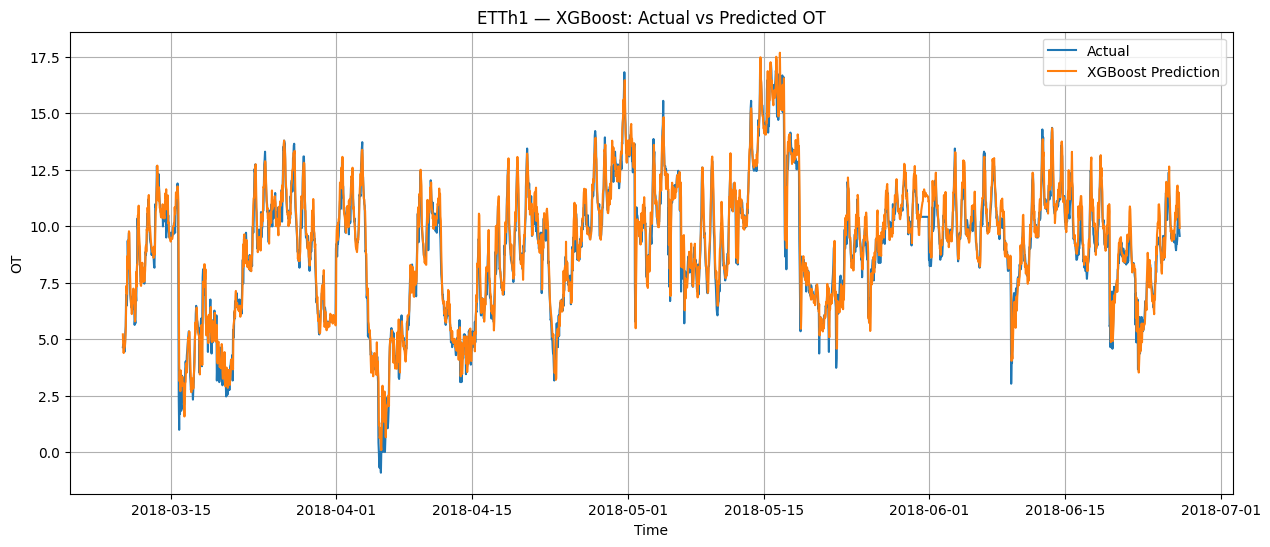

In [18]:
plt.figure(figsize=(15, 6))

plt.plot(
    results["date"],
    results["actual"],
    label="Actual"
)

plt.plot(
    results["date"],
    results["predicted"],
    label="XGBoost Prediction"
)

plt.xlabel("Time")
plt.ylabel("OT")

plt.title(
    "ETTh1 — XGBoost: Actual vs Predicted OT"
)

plt.legend()

plt.grid(True)

plt.show()

In [19]:
importance = pd.DataFrame({

    "feature": X_train.columns,

    "importance": model.feature_importances_

})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print("\nTop 20 most important features:")

display(
    importance.head(20)
)


Top 20 most important features:


,feature,importance
144,OT_lag_1,0.672726
145,OT_lag_2,0.123681
146,OT_lag_3,0.075685
148,OT_lag_5,0.014906
165,OT_lag_22,0.007278
166,OT_lag_23,0.005083
163,OT_lag_20,0.003318
167,OT_lag_24,0.002143
48,MUFL_lag_1,0.001586
96,LUFL_lag_1,0.001526
